Patches extracted: (126, 64, 64)
Label distribution: [59 67]
  Arrested (0): 59
  Divided  (1): 67
Saved to data/features/


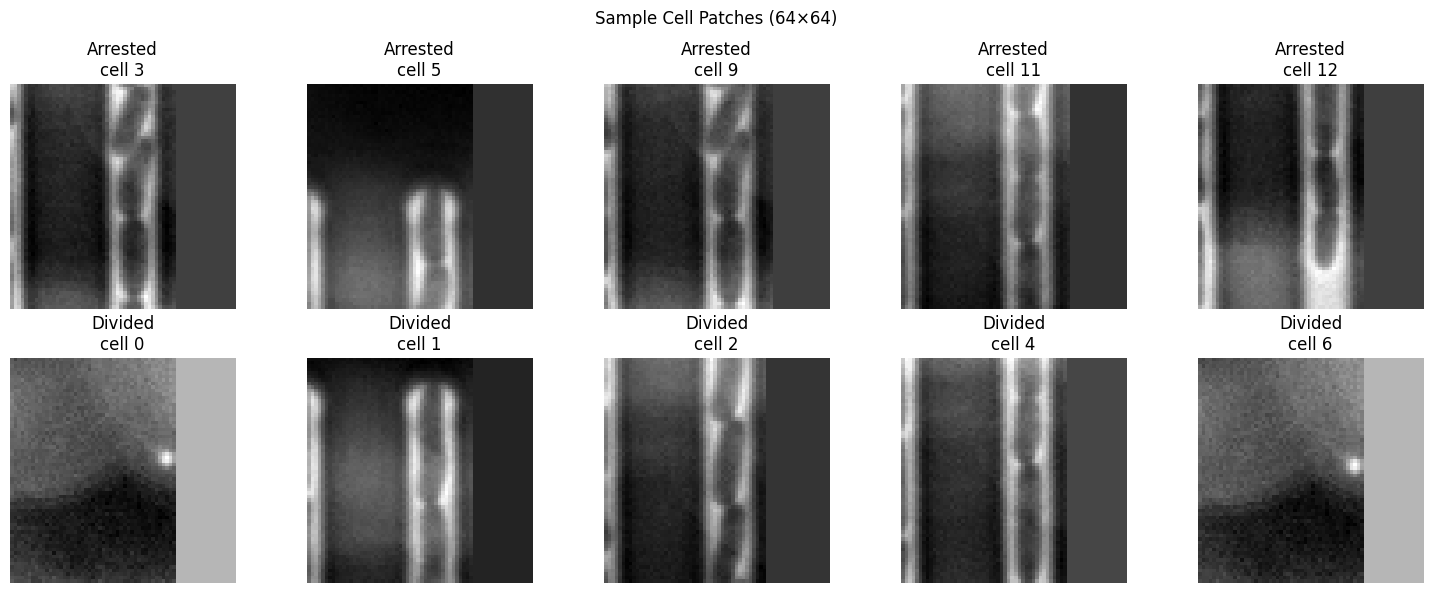

In [3]:
import scipy.io, tifffile, numpy as np, pandas as pd, os, sys
from skimage import measure
sys.path.append('../src')

if 'preprocessing' in sys.modules:
    del sys.modules['preprocessing']
from preprocessing import preprocess_image

DELTA_PATH = '../data/raw/delta/tests/data/movie_mothermachine_tif'
MAT_DIR    = os.path.join(DELTA_PATH, 'expected_results')
TIF_TEMPLATE = os.path.join(DELTA_PATH, 'Position{p:02d}Channel{c:02d}Frames{t:06d}.tif')

PATCH_SIZE = 64
patches, labels, meta = [], [], []

for mat_file in sorted(os.listdir(MAT_DIR)):
    if not mat_file.endswith('.mat'):
        continue
    pos_idx = int(mat_file.replace('Position', '').replace('.mat', ''))
    mat = scipy.io.loadmat(os.path.join(MAT_DIR, mat_file), simplify_cells=False)
    res = mat['res']
    
    for ch_idx in range(res.shape[1]):
        chamber = res[0, ch_idx]
        labelsstack = chamber['labelsstack'][0, 0]  # (T, H, W)
        lineage_arr = chamber['lineage'][0, 0]
        if lineage_arr.size == 0:
            continue
        
        n_cells  = lineage_arr.shape[1]
        n_frames = labelsstack.shape[0]
        
        # Load all TIF frames for this position
        imgs = {}
        for t in range(1, n_frames + 1):
            tif_path = TIF_TEMPLATE.format(p=pos_idx+1, c=1, t=t)
            if os.path.exists(tif_path):
                imgs[t] = preprocess_image(tifffile.imread(tif_path))
        
        if len(imgs) == 0:
            continue
        
        for cell_idx in range(n_cells):
            cell = lineage_arr[0, cell_idx]
            
            try:
                # ── FIXED: unwrap the extra (1,1) layer ──
                frames    = cell['frames'][0, 0][0].astype(int)
                daughters = cell['daughters'][0, 0][0]
                divided   = int(np.any(daughters > 0))
            except Exception as e:
                print(f"  Skipping cell {cell_idx} ch {ch_idx}: {e}")
                continue
            
            # Middle frame
            mid_frame_idx = len(frames) // 2
            frame_num = frames[mid_frame_idx]
            
            if frame_num not in imgs:
                continue
            img = imgs[frame_num]
            
            mask_frame = labelsstack[frame_num - 1]
            cell_label_in_mask = cell_idx + 1  # 1-indexed
            cell_mask = (mask_frame == cell_label_in_mask)
            
            if not cell_mask.any():
                continue
            
            props = measure.regionprops(cell_mask.astype(int))
            if len(props) == 0:
                continue
            cy, cx = props[0].centroid
            cy, cx = int(cy), int(cx)
            half = PATCH_SIZE // 2
            
            r0 = max(0, cy - half)
            r1 = min(img.shape[0], cy + half)
            c0 = max(0, cx - half)
            c1 = min(img.shape[1], cx + half)
            patch = img[r0:r1, c0:c1]
            
            # Pad if needed
            if patch.shape != (PATCH_SIZE, PATCH_SIZE):
                padded = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.float32)
                padded[:patch.shape[0], :patch.shape[1]] = patch
                patch = padded
            
            patches.append(patch.astype(np.float32))
            labels.append(divided)
            meta.append({
                'mat_file'  : mat_file,
                'chamber'   : ch_idx,
                'cell_id'   : cell_idx,
                'frame'     : frame_num
            })

patches = np.array(patches)
labels  = np.array(labels)

print(f"Patches extracted: {patches.shape}")
print(f"Label distribution: {np.bincount(labels)}")
print(f"  Arrested (0): {(labels==0).sum()}")
print(f"  Divided  (1): {(labels==1).sum()}")

# Save
os.makedirs('../data/features', exist_ok=True)
np.save('../data/features/cell_patches.npy', patches)
np.save('../data/features/cell_labels.npy', labels)
pd.DataFrame(meta).to_csv('../data/features/patch_meta.csv', index=False)
print("Saved to data/features/")

# Visualize a few patches
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes[0]):
    idx = np.where(labels==0)[0][i]
    ax.imshow(patches[idx], cmap='gray')
    ax.set_title(f'Arrested\ncell {idx}')
    ax.axis('off')
for i, ax in enumerate(axes[1]):
    idx = np.where(labels==1)[0][i]
    ax.imshow(patches[idx], cmap='gray')
    ax.set_title(f'Divided\ncell {idx}')
    ax.axis('off')
plt.suptitle('Sample Cell Patches (64×64)')
plt.tight_layout()
plt.savefig('../outputs/figures/week5_sample_patches.png', dpi=150)
plt.show()